# Task 5: Optimize the Number of Retrieved Chunks

This notebook studies the effect of the number of retrieved context chunks, denoted by `m`, on retrieval-augmented generation performance.

The architecture is fixed to the best-performing configuration selected earlier:

- sentence chunking with 3 sentences and overlap 1
- HNSW first-stage retrieval with `M=32`, `efConstruction=120`, metric `euclidean`
- sequential reranker
- generator model: `qwen2.5:1.5b`

The only parameter varied in this notebook is `m`, the number of final reranked chunks passed to the generator.

Evaluation is performed against `question.tsv` using:

- `exact_match`
- `transformer_match`

Results are reported:

- overall
- stratified by `DifficultyFromAnswerer` (`easy`, `medium`, `hard`)

The goal is to identify the most effective value of `m` and discuss why that choice makes sense for this dataset.


In [1]:
import os
import sys
import time
import json
from pathlib import Path
from typing import List, Dict, Any, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from openai import OpenAI


In [2]:
from pathlib import Path
import sys

def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current] + list(current.parents):
        if (candidate / "textwave").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing the 'textwave' directory.")

PROJECT_ROOT = find_project_root(Path.cwd())

for p in [PROJECT_ROOT, PROJECT_ROOT.parent]:
    p_str = str(p)
    if p_str not in sys.path:
        sys.path.insert(0, p_str)

print("Project root:", PROJECT_ROOT)


Project root: C:\Users\Usuario\Downloads\textwave-hortner87-main(1)\textwave-hortner87-main


In [3]:
from textwave.modules.extraction.preprocessing import DocumentProcessing
from textwave.modules.extraction.embedding import Embedding
from textwave.modules.utils.metrics import Matching
from textwave.modules.retrieval.reranker import Reranker
from hnsw import FaissHNSW


## Configuration

This notebook keeps the architecture fixed and varies only `m`, the number of final reranked chunks passed to the generator.


In [4]:
QUESTIONS_PATH = PROJECT_ROOT / "textwave" / "qa_resources" / "question.tsv"
CORPUS_DIR = PROJECT_ROOT / "textwave" / "storage"

RESULTS_DIR = PROJECT_ROOT / "analysis" / "results" / "task5_optimize_m"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

EMBEDDING_MODEL_NAME = "all-MiniLM-L6-v2"

CHUNKING_CONFIG = {"num_sentences": 3, "overlap_size": 1}
HNSW_CONFIG = {"M": 32, "efConstruction": 120, "metric": "euclidean"}

GENERATOR_MODEL = "qwen2.5:1.5b"
RERANKER_TYPE = "sequential"

OLLAMA_BASE_URL = os.getenv("OLLAMA_BASE_URL", "http://localhost:11434/v1")
OLLAMA_API_KEY = os.getenv("OLLAMA_API_KEY", "ollama")
TEMPERATURE = 0.2

TOP_K_CANDIDATE_POOL = 50
SEQUENTIAL_K1 = 20

M_VALUES = [1, 2, 3, 4, 5, 6, 7, 8]

MAX_QUESTIONS = None
SAVE_EVERY = 25
CHUNK_EMBED_BATCH_SIZE = 256
QUERY_EMBED_BATCH_SIZE = 256

print("Questions path:", QUESTIONS_PATH)
print("Corpus dir:", CORPUS_DIR)
print("Results dir:", RESULTS_DIR)
print("Generator model:", GENERATOR_MODEL)
print("Reranker:", RERANKER_TYPE)
print("M values:", M_VALUES)


Questions path: C:\Users\Usuario\Downloads\textwave-hortner87-main(1)\textwave-hortner87-main\textwave\qa_resources\question.tsv
Corpus dir: C:\Users\Usuario\Downloads\textwave-hortner87-main(1)\textwave-hortner87-main\textwave\storage
Results dir: C:\Users\Usuario\Downloads\textwave-hortner87-main(1)\textwave-hortner87-main\analysis\results\task5_optimize_m
Generator model: qwen2.5:1.5b
Reranker: sequential
M values: [1, 2, 3, 4, 5, 6, 7, 8]


## Load and clean the evaluation set

We reuse the same benchmark and the same cleaning logic as in the earlier RAG notebooks so that differences can be attributed to `m` rather than to a changed evaluation subset.


In [5]:
def normalize_article_id(value: str) -> str:
    value = Path(str(value)).name
    for suffix in [".txt.clean", ".clean", ".txt"]:
        if value.endswith(suffix):
            value = value[:-len(suffix)]
    return value

def safe_text(x) -> str:
    try:
        if pd.isna(x):
            return ""
    except Exception:
        pass
    return x if isinstance(x, str) else str(x)

ANSWER_COLUMN_CANDIDATES = [
    "Answer", "Answers", "answer", "answers",
    "GoldAnswer", "gold_answer", "ExpectedAnswer", "expected_answer"
]

questions_df = pd.read_csv(QUESTIONS_PATH, sep="\t")
ANSWER_COLUMN = next((col for col in ANSWER_COLUMN_CANDIDATES if col in questions_df.columns), None)
if ANSWER_COLUMN is None:
    raise KeyError("Could not find an answer column in question.tsv.")

corpus_files = sorted(CORPUS_DIR.glob("*.clean"))
available_article_ids = {normalize_article_id(path.name) for path in corpus_files}

questions_df["question_text"] = questions_df["Question"].apply(safe_text)
questions_df["gold_answer"] = questions_df[ANSWER_COLUMN].apply(safe_text)
questions_df["article_id_norm"] = questions_df["ArticleFile"].apply(safe_text).map(normalize_article_id)
questions_df["difficulty"] = questions_df["DifficultyFromAnswerer"].apply(safe_text).str.strip().str.lower()

questions_df = questions_df[
    (questions_df["question_text"].str.strip() != "") &
    (questions_df["gold_answer"].str.strip() != "") &
    (questions_df["article_id_norm"].str.strip() != "") &
    (questions_df["article_id_norm"].isin(available_article_ids))
].copy()

if MAX_QUESTIONS is not None:
    questions_df = questions_df.head(MAX_QUESTIONS).copy()

questions_df = questions_df.reset_index(drop=True)
questions_df["row_id"] = np.arange(len(questions_df))

print("Questions kept:", len(questions_df))
display(questions_df["difficulty"].value_counts(dropna=False).rename_axis("difficulty").reset_index(name="rows"))
display(questions_df.head())


Questions kept: 838


,difficulty,rows
0,easy,322
1,medium,304
2,hard,181
3,too hard,25
4,too easy,6


,ArticleTitle,Question,Answer,DifficultyFromQuestioner,DifficultyFromAnswerer,ArticleFile,question_text,gold_answer,article_id_norm,difficulty,row_id
0,Abraham_Lincoln,Was Abraham Lincoln the sixteenth President of...,yes,easy,easy,S08_set3_a4,Was Abraham Lincoln the sixteenth President of...,yes,S08_set3_a4,easy,0
1,Abraham_Lincoln,Was Abraham Lincoln the sixteenth President of...,Yes.,easy,easy,S08_set3_a4,Was Abraham Lincoln the sixteenth President of...,Yes.,S08_set3_a4,easy,1
2,Abraham_Lincoln,Did Lincoln sign the National Banking Act of 1...,yes,easy,medium,S08_set3_a4,Did Lincoln sign the National Banking Act of 1...,yes,S08_set3_a4,medium,2
3,Abraham_Lincoln,Did Lincoln sign the National Banking Act of 1...,Yes.,easy,easy,S08_set3_a4,Did Lincoln sign the National Banking Act of 1...,Yes.,S08_set3_a4,easy,3
4,Abraham_Lincoln,Did his mother die of pneumonia?,no,easy,medium,S08_set3_a4,Did his mother die of pneumonia?,no,S08_set3_a4,medium,4


## Build the fixed chunk representation

The corpus is chunked using the selected sentence-based strategy from earlier tasks.


In [6]:
processor = DocumentProcessing()
embedder = Embedding(EMBEDDING_MODEL_NAME)
matcher = Matching()

def build_chunk_table(
    corpus_paths: List[Path],
    processor: DocumentProcessing,
    num_sentences: int,
    overlap_size: int,
) -> pd.DataFrame:
    rows = []

    for file_path in corpus_paths:
        article_file = file_path.name
        article_id = normalize_article_id(article_file)

        chunks = processor.sentence_chunking(
            str(file_path),
            num_sentences=num_sentences,
            overlap_size=overlap_size,
        )

        for chunk_order, chunk_text in enumerate(chunks):
            rows.append(
                {
                    "chunk_id": len(rows),
                    "article_file": article_file,
                    "article_id": article_id,
                    "chunk_text": safe_text(chunk_text),
                    "chunk_order": chunk_order,
                }
            )

    chunk_df = pd.DataFrame(rows)
    if not chunk_df.empty:
        chunk_df["chunk_id"] = np.arange(len(chunk_df))
    return chunk_df

chunk_df = build_chunk_table(
    corpus_paths=corpus_files,
    processor=processor,
    num_sentences=CHUNKING_CONFIG["num_sentences"],
    overlap_size=CHUNKING_CONFIG["overlap_size"],
)

print("Chunk count:", len(chunk_df))
display(chunk_df.head())


Using device: cpu
Chunk count: 17161


,chunk_id,article_file,article_id,chunk_text,chunk_order
0,0,S08_set1_a1.txt.clean,S08_set1_a1,kangaroo A kangaroo is a marsupial from the fa...,0
1,1,S08_set1_a1.txt.clean,S08_set1_a1,The family also includes many smaller species ...,1
2,2,S08_set1_a1.txt.clean,S08_set1_a1,"In general, larger kangaroos have adapted much...",2
3,3,S08_set1_a1.txt.clean,S08_set1_a1,"Steve Dow: ""An industry that's under the gun""....",3
4,4,S08_set1_a1.txt.clean,S08_set1_a1,The kangaroo is an Australian icon: it is feat...,4


## Build the HNSW retriever

To stay memory efficient, chunk embeddings are encoded in batches and added to the index incrementally.


In [7]:
def encode_texts_in_batches(texts: List[str], embedder: Embedding, batch_size: int) -> np.ndarray:
    batches = []
    for start in range(0, len(texts), batch_size):
        batch_texts = texts[start:start + batch_size]
        batch_vectors = embedder.encode(batch_texts)
        batch_vectors = np.asarray(batch_vectors, dtype=np.float32)
        if batch_vectors.ndim == 1:
            batch_vectors = batch_vectors.reshape(1, -1)
        batches.append(batch_vectors)
    return np.vstack(batches)

def build_hnsw_index_incremental(
    chunk_df: pd.DataFrame,
    embedder: Embedding,
    batch_size: int,
    **kwargs,
):
    probe_vec = embedder.encode([safe_text(chunk_df.iloc[0]["chunk_text"])])
    probe_vec = np.asarray(probe_vec, dtype=np.float32)
    if probe_vec.ndim == 1:
        probe_vec = probe_vec.reshape(1, -1)

    index = FaissHNSW(dim=probe_vec.shape[1], **kwargs)

    for start in range(0, len(chunk_df), batch_size):
        batch_df = chunk_df.iloc[start:start + batch_size]
        batch_embeddings = embedder.encode(batch_df["chunk_text"].tolist())
        batch_embeddings = np.asarray(batch_embeddings, dtype=np.float32)
        if batch_embeddings.ndim == 1:
            batch_embeddings = batch_embeddings.reshape(1, -1)

        index.add_embeddings(batch_embeddings, batch_df["chunk_id"].tolist())

    return index

hnsw_index = build_hnsw_index_incremental(
    chunk_df=chunk_df,
    embedder=embedder,
    batch_size=CHUNK_EMBED_BATCH_SIZE,
    **HNSW_CONFIG,
)

print("HNSW index built.")


HNSW index built.


## Encode the evaluation questions and retrieve candidate pools

The first-stage HNSW candidate pool is computed once and reused across all values of `m`.


In [8]:
question_embeddings = encode_texts_in_batches(
    questions_df["question_text"].tolist(),
    embedder=embedder,
    batch_size=QUERY_EMBED_BATCH_SIZE,
)

def search_hnsw_indices(index_obj, query_vector: np.ndarray, top_k: int) -> np.ndarray:
    query_vector = np.asarray(query_vector, dtype=np.float32).reshape(1, -1)
    distances, indices = index_obj.index.search(query_vector, top_k)
    valid_indices = [int(i) for i in indices[0] if int(i) >= 0]
    return np.asarray(valid_indices, dtype=int)

candidate_pool_records = []
for i, row in questions_df.iterrows():
    candidate_ids = search_hnsw_indices(hnsw_index, question_embeddings[i], TOP_K_CANDIDATE_POOL)
    candidate_pool_records.append(
        {
            "row_id": int(row["row_id"]),
            "candidate_chunk_ids": json.dumps(candidate_ids.tolist()),
        }
    )

candidate_pool_df = pd.DataFrame(candidate_pool_records)
display(candidate_pool_df.head())


,row_id,candidate_chunk_ids
0,0,"[3023, 3114, 3027, 3033, 3055, 3185, 3221, 320..."
1,1,"[3023, 3114, 3027, 3033, 3055, 3185, 3221, 320..."
2,2,"[3189, 3187, 3190, 3180, 3127, 3092, 3179, 316..."
3,3,"[3189, 3187, 3190, 3180, 3127, 3092, 3179, 316..."
4,4,"[3786, 4823, 8604, 16769, 14490, 16230, 3781, ..."


## Apply the sequential reranker once

Since the architecture is fixed, reranking is performed once and the final ordered chunk list is reused while varying `m`.


In [9]:
def get_candidate_texts(candidate_chunk_ids: List[int], chunk_df: pd.DataFrame) -> List[str]:
    return chunk_df.iloc[candidate_chunk_ids]["chunk_text"].tolist()

def precompute_sequential_reranked_lists(
    questions: pd.DataFrame,
    candidate_pool_df: pd.DataFrame,
    chunk_df: pd.DataFrame,
    seq_k1: int,
):
    reranker = Reranker(type="sequential")
    records = []

    pool_map = {
        int(row["row_id"]): json.loads(row["candidate_chunk_ids"])
        for _, row in candidate_pool_df.iterrows()
    }

    for _, row in questions.iterrows():
        row_id = int(row["row_id"])
        candidate_chunk_ids = pool_map[row_id]
        candidate_texts = get_candidate_texts(candidate_chunk_ids, chunk_df)

        _, local_indices, _ = reranker.rerank(
            query=row["question_text"],
            context=candidate_texts,
            distance_metric="cosine",
            seq_k1=min(seq_k1, len(candidate_texts)),
            seq_k2=len(candidate_texts),
        )

        reranked_chunk_ids = [
            int(candidate_chunk_ids[idx])
            for idx in list(local_indices)
            if idx < len(candidate_chunk_ids)
        ]

        records.append(
            {
                "row_id": row_id,
                "reranked_chunk_ids": json.dumps(reranked_chunk_ids),
            }
        )

    return pd.DataFrame(records)

reranked_df = precompute_sequential_reranked_lists(
    questions=questions_df,
    candidate_pool_df=candidate_pool_df,
    chunk_df=chunk_df,
    seq_k1=SEQUENTIAL_K1,
)

display(reranked_df.head())


,row_id,reranked_chunk_ids
0,0,"[3023, 3027, 3119, 3114, 3232, 3134, 3231, 301..."
1,1,"[3023, 3027, 3119, 3114, 3232, 3134, 3231, 301..."
2,2,"[3189, 3190, 3187, 3180, 3179, 3027, 3028, 316..."
3,3,"[3189, 3190, 3187, 3180, 3179, 3027, 3028, 316..."
4,4,"[16230, 16231, 3889, 14490, 4823, 8604, 16676,..."


## Generator and scoring helpers

These match the Task 3/4 setup so that only `m` changes across runs.


In [10]:
class RAGGeneratorOpenAI:
    def __init__(
        self,
        api_key: str = OLLAMA_API_KEY,
        temperature: float = TEMPERATURE,
        generator_model: str = GENERATOR_MODEL,
        base_url: str = OLLAMA_BASE_URL,
    ):
        self.api_key = api_key
        self.temperature = temperature
        self.generator_model = generator_model
        self.client = OpenAI(api_key=api_key, base_url=base_url)

    def generate_answer(self, query: str, context: List[str]) -> str:
        combined_input = (
            f"Question: {safe_text(query)}\n\n"
            f"Context: {', '.join([safe_text(chunk) for chunk in context])}\n\n"
        )

        response = self.client.chat.completions.create(
            model=self.generator_model,
            temperature=self.temperature,
            messages=[
                {
                    "role": "system",
                    "content": (
                        "You must answer the user's questions only based "
                        "on the provided context. Do not use any external or prior knowledge. "
                        "Provide clear, concise, and full-sentence answers. "
                        "If the context does not mention the answer, respond with 'No context'."
                    ),
                },
                {
                    "role": "user",
                    "content": combined_input,
                },
            ],
        )

        return safe_text(response.choices[0].message.content).strip()

def score_single_answer(question: str, gold_answer: str, generated_answer: str) -> Dict[str, Any]:
    em = matcher.exact_match(safe_text(generated_answer), safe_text(gold_answer))

    try:
        _, transformer_match = matcher.transformer_match(
            generated_answer=safe_text(generated_answer),
            ground_truth_answer=safe_text(gold_answer),
            question=safe_text(question),
        )
    except Exception:
        transformer_match = np.nan

    return {
        "exact_match": float(bool(em)),
        "transformer_match": float(bool(transformer_match)) if not pd.isna(transformer_match) else np.nan,
    }


## Sweep over `m`

For each value of `m`, the notebook takes the top-`m` reranked chunks, generates answers with qwen, and scores the outputs.


In [11]:
def run_m_experiment(
    m: int,
    questions: pd.DataFrame,
    reranked_df: pd.DataFrame,
    chunk_df: pd.DataFrame,
    save_every: int = SAVE_EVERY,
) -> pd.DataFrame:
    generator = RAGGeneratorOpenAI(generator_model=GENERATOR_MODEL)
    rows = []

    reranked_map = {
        int(row["row_id"]): json.loads(row["reranked_chunk_ids"])
        for _, row in reranked_df.iterrows()
    }

    output_path = RESULTS_DIR / f"task5_m_{m}.csv"
    start_all = time.perf_counter()

    for i, row in questions.iterrows():
        row_id = int(row["row_id"])
        reranked_chunk_ids = reranked_map[row_id][:m]
        context_chunks = chunk_df.iloc[reranked_chunk_ids]["chunk_text"].tolist()

        error_text = ""
        generated_answer = ""

        t0 = time.perf_counter()
        try:
            generated_answer = generator.generate_answer(row["question_text"], context_chunks)
        except Exception as e:
            error_text = str(e)
        latency_sec = time.perf_counter() - t0

        if error_text:
            score_dict = {"exact_match": 0.0, "transformer_match": np.nan}
        else:
            score_dict = score_single_answer(row["question_text"], row["gold_answer"], generated_answer)

        rows.append(
            {
                "row_id": row_id,
                "m": m,
                "question": row["question_text"],
                "gold_answer": row["gold_answer"],
                "difficulty": row["difficulty"],
                "article_id_norm": row["article_id_norm"],
                "reranked_chunk_ids": json.dumps(reranked_chunk_ids),
                "generated_answer": generated_answer,
                "generation_error": error_text,
                "latency_sec": latency_sec,
                **score_dict,
            }
        )

        if (i + 1) % save_every == 0 or (i + 1) == len(questions):
            pd.DataFrame(rows).to_csv(output_path, index=False)
            elapsed_min = (time.perf_counter() - start_all) / 60
            avg_per_q = (time.perf_counter() - start_all) / max(i + 1, 1)
            print(f"[m={m}] {i+1}/{len(questions)} done | elapsed: {elapsed_min:.1f} min | avg/question: {avg_per_q:.2f} sec")

    return pd.DataFrame(rows)


In [12]:
all_results = []

for m in M_VALUES:
    print(f"\nRunning experiment for m = {m}")
    m_df = run_m_experiment(
        m=m,
        questions=questions_df,
        reranked_df=reranked_df,
        chunk_df=chunk_df,
    )
    all_results.append(m_df)

all_results_df = pd.concat(all_results, ignore_index=True)
all_results_path = RESULTS_DIR / "task5_optimize_m_all_results.csv"
all_results_df.to_csv(all_results_path, index=False)

print("Saved combined results to:", all_results_path)
display(all_results_df.head())



Running experiment for m = 1
[m=1] 25/838 done | elapsed: 2.9 min | avg/question: 6.87 sec
[m=1] 50/838 done | elapsed: 7.7 min | avg/question: 9.29 sec
[m=1] 75/838 done | elapsed: 10.5 min | avg/question: 8.44 sec
[m=1] 100/838 done | elapsed: 13.7 min | avg/question: 8.20 sec
[m=1] 125/838 done | elapsed: 16.7 min | avg/question: 8.02 sec
[m=1] 150/838 done | elapsed: 19.9 min | avg/question: 7.95 sec
[m=1] 175/838 done | elapsed: 22.9 min | avg/question: 7.85 sec
[m=1] 200/838 done | elapsed: 27.0 min | avg/question: 8.09 sec
[m=1] 225/838 done | elapsed: 30.5 min | avg/question: 8.13 sec
[m=1] 250/838 done | elapsed: 33.8 min | avg/question: 8.11 sec
[m=1] 275/838 done | elapsed: 38.4 min | avg/question: 8.39 sec
[m=1] 300/838 done | elapsed: 44.6 min | avg/question: 8.93 sec
[m=1] 325/838 done | elapsed: 48.1 min | avg/question: 8.88 sec
[m=1] 350/838 done | elapsed: 52.6 min | avg/question: 9.02 sec
[m=1] 375/838 done | elapsed: 55.2 min | avg/question: 8.83 sec
[m=1] 400/838 d

,row_id,m,question,gold_answer,difficulty,article_id_norm,reranked_chunk_ids,generated_answer,generation_error,latency_sec,exact_match,transformer_match
0,0,1,Was Abraham Lincoln the sixteenth President of...,yes,easy,S08_set3_a4,[3023],"Yes, Abraham Lincoln was indeed the sixteenth ...",,9.505379,1.0,1.0
1,1,1,Was Abraham Lincoln the sixteenth President of...,Yes.,easy,S08_set3_a4,[3023],"Yes, Abraham Lincoln was indeed the sixteenth ...",,0.742202,1.0,1.0
2,2,1,Did Lincoln sign the National Banking Act of 1...,yes,medium,S08_set3_a4,[3189],No context,,1.691604,0.0,0.0
3,3,1,Did Lincoln sign the National Banking Act of 1...,Yes.,easy,S08_set3_a4,[3189],No context,,2.348733,0.0,0.0
4,4,1,Did his mother die of pneumonia?,no,medium,S08_set3_a4,[16230],No context.,,3.147032,1.0,1.0


## Overall and difficulty-stratified summaries

In [13]:
overall_summary = (
    all_results_df
    .groupby("m", dropna=False)
    .agg(
        rows=("row_id", "count"),
        exact_match=("exact_match", "mean"),
        transformer_match=("transformer_match", "mean"),
        latency_sec=("latency_sec", "mean"),
    )
    .reset_index()
    .sort_values("m")
)

difficulty_summary = (
    all_results_df[all_results_df["difficulty"].isin(["easy", "medium", "hard"])]
    .groupby(["m", "difficulty"], dropna=False)
    .agg(
        rows=("row_id", "count"),
        exact_match=("exact_match", "mean"),
        transformer_match=("transformer_match", "mean"),
        latency_sec=("latency_sec", "mean"),
    )
    .reset_index()
    .sort_values(["m", "difficulty"])
)

display(overall_summary)
display(difficulty_summary)


,m,rows,exact_match,transformer_match,latency_sec
0,1,838,0.557279,0.652745,2.996471
1,2,838,0.591885,0.676611,3.946489
2,3,838,0.621718,0.702864,5.134621
3,4,838,0.622912,0.701671,7.570235
4,5,838,0.606205,0.692124,8.945026
5,6,838,0.610979,0.687351,7.253178
6,7,838,0.599045,0.687351,7.979795
7,8,838,0.614558,0.694511,10.888797


,m,difficulty,rows,exact_match,transformer_match,latency_sec
0,1,easy,322,0.770186,0.816770,2.633811
1,1,hard,181,0.309392,0.408840,3.591752
2,1,medium,304,0.500000,0.644737,2.999382
3,2,easy,322,0.788820,0.832298,3.664277
4,2,hard,181,0.364641,0.508287,4.540711
5,2,medium,304,0.539474,0.634868,3.871579
6,3,easy,322,0.819876,0.847826,5.009866
7,3,hard,181,0.386740,0.497238,5.543019
8,3,medium,304,0.582237,0.700658,4.998123
9,4,easy,322,0.813665,0.841615,7.753614


In [20]:
overall_summary = (
    all_results_df
    .groupby("m", dropna=False)
    .agg(
        rows=("row_id", "count"),
        exact_match=("exact_match", "mean"),
        transformer_match=("transformer_match", "mean"),
        latency_sec=("latency_sec", "mean"),
    )
    .reset_index()
    .sort_values("m")
)

difficulty_summary = (
    all_results_df[all_results_df["difficulty"].isin(["easy", "medium", "hard", "too easy", "too hard"])]
    .groupby(["m", "difficulty"], dropna=False)
    .agg(
        rows=("row_id", "count"),
        exact_match=("exact_match", "mean"),
        transformer_match=("transformer_match", "mean"),
        latency_sec=("latency_sec", "mean"),
    )
    .reset_index()
    .sort_values(["m", "difficulty"])
)

display(overall_summary)
display(difficulty_summary)


,m,rows,exact_match,transformer_match,latency_sec
0,1,838,0.557279,0.652745,2.996471
1,2,838,0.591885,0.676611,3.946489
2,3,838,0.621718,0.702864,5.134621
3,4,838,0.622912,0.701671,7.570235
4,5,838,0.606205,0.692124,8.945026
5,6,838,0.610979,0.687351,7.253178
6,7,838,0.599045,0.687351,7.979795
7,8,838,0.614558,0.694511,10.888797


,m,difficulty,rows,exact_match,transformer_match,latency_sec
0,1,easy,322,0.770186,0.816770,2.633811
1,1,hard,181,0.309392,0.408840,3.591752
2,1,medium,304,0.500000,0.644737,2.999382
3,1,too easy,6,0.666667,0.666667,2.319237
4,1,too hard,25,0.280000,0.400000,3.484850
5,2,easy,322,0.788820,0.832298,3.664277
6,2,hard,181,0.364641,0.508287,4.540711
7,2,medium,304,0.539474,0.634868,3.871579
8,2,too easy,6,0.666667,0.666667,2.914293
9,2,too hard,25,0.320000,0.400000,4.437856


## Visual summaries

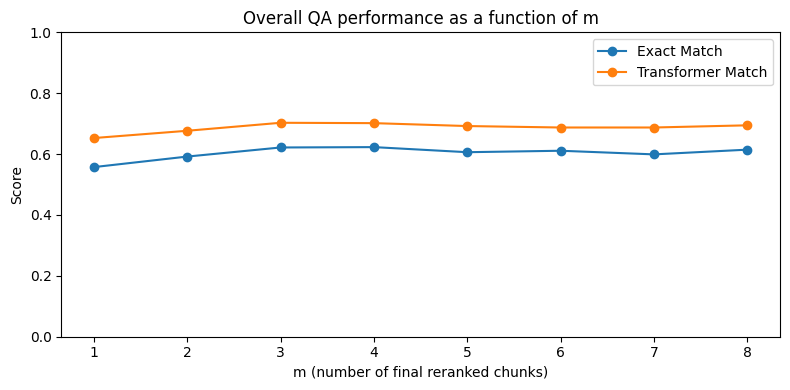

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(overall_summary["m"], overall_summary["exact_match"], marker="o", label="Exact Match")
ax.plot(overall_summary["m"], overall_summary["transformer_match"], marker="o", label="Transformer Match")

ax.set_xlabel("m (number of final reranked chunks)")
ax.set_ylabel("Score")
ax.set_title("Overall QA performance as a function of m")
ax.set_xticks(overall_summary["m"])
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()


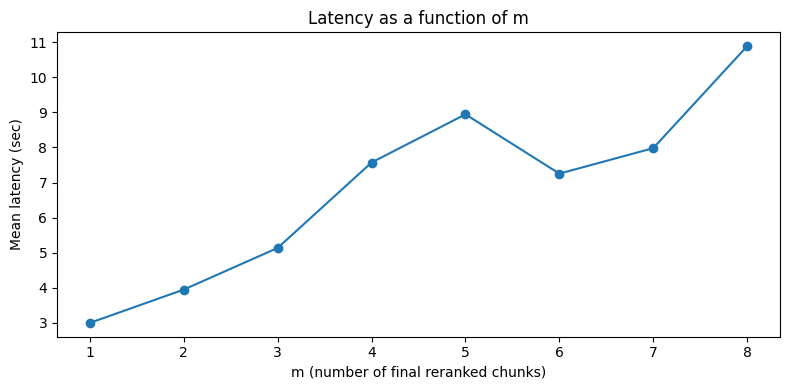

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(overall_summary["m"], overall_summary["latency_sec"], marker="o")

ax.set_xlabel("m (number of final reranked chunks)")
ax.set_ylabel("Mean latency (sec)")
ax.set_title("Latency as a function of m")
ax.set_xticks(overall_summary["m"])
plt.tight_layout()
plt.show()


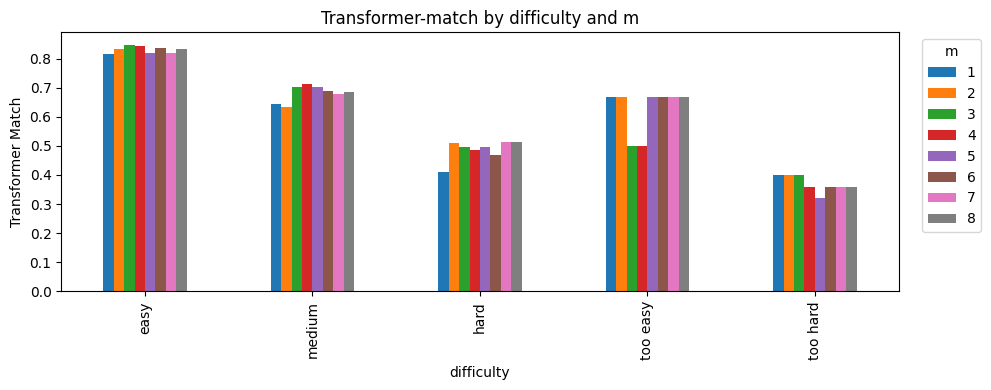

In [21]:
pivot_df = (
    difficulty_summary
    .pivot(index="difficulty", columns="m", values="transformer_match")
    .reindex(["easy", "medium", "hard", "too easy", "too hard"])
)

fig, ax = plt.subplots(figsize=(10, 4))
pivot_df.plot(kind="bar", ax=ax)

ax.set_ylabel("Transformer Match")
ax.set_title("Transformer-match by difficulty and m")
ax.legend(title="m", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## Choose the optimal `m`

The preferred value of `m` should be selected primarily using `transformer_match`, with `exact_match` and latency used as supporting criteria.


In [17]:
best_row = overall_summary.sort_values(
    ["transformer_match", "exact_match", "latency_sec"],
    ascending=[False, False, True]
).iloc[0]

print("Suggested optimal m:")
display(best_row.to_frame().T)


Suggested optimal m:


,m,rows,exact_match,transformer_match,latency_sec
2,3.0,838.0,0.621718,0.702864,5.134621


## Qualitative inspection

Looking at a few examples helps determine whether larger `m` values provide genuinely useful extra evidence or simply add redundant and distracting context.


In [18]:
display(
    all_results_df[
        ["m", "difficulty", "question", "gold_answer", "generated_answer", "exact_match", "transformer_match"]
    ].head(30)
)


,m,difficulty,question,gold_answer,generated_answer,exact_match,transformer_match
0,1,easy,Was Abraham Lincoln the sixteenth President of...,yes,"Yes, Abraham Lincoln was indeed the sixteenth ...",1.0,1.0
1,1,easy,Was Abraham Lincoln the sixteenth President of...,Yes.,"Yes, Abraham Lincoln was indeed the sixteenth ...",1.0,1.0
2,1,medium,Did Lincoln sign the National Banking Act of 1...,yes,No context,0.0,0.0
3,1,easy,Did Lincoln sign the National Banking Act of 1...,Yes.,No context,0.0,0.0
4,1,medium,Did his mother die of pneumonia?,no,No context.,1.0,1.0
5,1,easy,Did his mother die of pneumonia?,No.,No context.,1.0,1.0
6,1,easy,How many long was Lincoln's formal education?,18 months,The provided context indicates that Lincoln's ...,1.0,1.0
7,1,medium,How many long was Lincoln's formal education?,18 months.,The provided context indicates that Lincoln's ...,1.0,1.0
8,1,easy,When did Lincoln begin his political career?,1832,Young Abraham Lincoln began his political care...,1.0,1.0
9,1,medium,When did Lincoln begin his political career?,1832.,Young Abraham Lincoln began his political care...,1.0,1.0
